In [ ]:
%load_ext autoreload
%autoreload 2

# Пример инференса модели Trivan через FMLib

In [ ]:
import pyarrow as pa
import pyarrow.fs as fs
import torch
from tqdm.autonotebook import tqdm

from fmlib.data.io import ParquetDataset
from fmlib.data.io.writer import PartitionedParquetWriter
from fmlib.nn.transforms import ChangePaddingTransform, TrivanTransform
from fmlib.pipeline import InferencePipeline
from fmlib.utils.loading import load_config, load_model
from fmlib.utils.mode_context import mode_context

## Создание даталоадера
### Даталоадер необходим для чтения файла по заданной структуре в метаданных. Даталоадер позволяет загрузить датасет в оперативную память частями, а не полностью

Обратите внимание, что формат подаваемого датасета отличается от оригинального в целях увеличения производительности!

В оригинальном варианте все "восьмерки" событий (время транзакции, день недели, день года, mcc_token, brand_token, place_token, terminal_token, amt_token) собирались в одной ячейке.

В предлагаемом "запеченом" формате информация о каждом токене хранится в отдельном столбце, объединенная в лист, который отсортирован по возрастанию времени транзакций. Такой датафрейм можно подготовить с использованием `PySpark` без `Pandas UDF`. Столбцы с датами `report_dt` и `evt_dttm` должны иметь формат `int64`, это можно получить, используя функцию `pyspark.sql.functions.unix_timestamp`. Для того чтобы избежать сдвигов времён из-за временных зон обязательно перед применением функции `unix_timestamp()` нужно сделать `spark.conf.set("spark.sql.session.timeZone", "UTC")`. Если не указать временную зону, то при определении дня недели и дня года будет сдвиг на 3 часа назад!
Обратите внимание, что в этом формате нигде не вычисляется день недели и день года, это происходит в `TrivanTransform()`.

In [ ]:
model_folder = "configs/inference/trivan"
device = "cuda:0"

_, metadata = load_config(model_folder, config_file="parquet_metadata.yaml")

dataloader = ParquetDataset(
    source="/user/team/team_amazme_okko/data/dskulandin/camomile/TRX_DATA_BAKED/",
    metadata=metadata,
    filesystem=fs.HadoopFileSystem("hdfs://arnsdpsbx", port=0),
    partition_size=1024,
    batch_size=16,
    device=device,
)

### Получение батча

In [ ]:
batch = next(iter(dataloader))
batch.keys()

## Инициализация Transform класса
### Этот класс необходим для обработки батча перед подачей в модель. Обратите внимание, что обработка может работать на GPU, это зависит от передаваемых в `Transform` тензоров
### Примеры операций, которые могут применяться в Transform:
- Фильтрация элементов
- Определение масок и маскирование
- Переименование/перегруппировка тензоров для совместимости с моделью
- Обработка вещественных значений - бакетизация, дискретизация
- Обработка категориальных значений - энкодинг

In [ ]:
transform = torch.nn.Sequential(
    ChangePaddingTransform("mcc_token_mask"),
    TrivanTransform(),
).to(device)
test_transformed = transform(batch)
test_transformed.keys()

## Ручная компиляция модели

### Загрузка модели в формате PyTorch

#### Для успешной загрузки необходимо указать путь до папки. В этой папке должна лежать вся информация необходимая для загрузки модели - веса и конфиг

In [ ]:
torch_model = load_model(model_folder)

## Создадим объект класса `InferencePipeline`
#### Пайплайн будет отвечать за трансформацию данных и подачу этих данных в модель.
#### В результате работы пайплайна вы получите преобразованный батч после применения Transform'ов и результат работы модели.
#### Обратите внимание, что `InferencePipeline` может принимать несколько Transform'ов. В таком случае будет выведен результат работы для каждого Transform отдельно (массив результатов)
#### Класс `InferencePipeline` является наследником `torch.nn.Module`. Поэтому вы свободно можете применять `torch.compile` к нему

In [ ]:
pipeline = InferencePipeline(model=torch_model, transform=transform).to(device)

In [ ]:
with torch.no_grad(), mode_context(pipeline, training=False):
    transformed_batch, model_logits = pipeline(batch)

In [ ]:
model_logits[0]["flower_offline_fr_1000_to_4000_d14"]

## Пример запуска полного цикла инференса и запись результата в `parquet`

In [ ]:
import tempfile

directory = tempfile.TemporaryDirectory()

In [ ]:
writer = PartitionedParquetWriter(base_path=f"{directory.name}/result", write_every_n_batch=128)

In [ ]:
with torch.no_grad(), mode_context(pipeline, training=False):
    for batch in tqdm(dataloader):
        transformed, model_logits = pipeline(batch)
        result = model_logits[0]
        for key in result:
            result[key] = torch.nn.functional.softmax(result[key], dim=-1)
        result["epk_id"] = batch["epk_id"]
        result["report_dt"] = batch["report_dt"]
        writer.write(result)

In [ ]:
writer.close()
writer.base_path

### Визуализация скоров

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
data = pa.parquet.read_table(writer.base_path)
scores = torch.asarray(data.column("flower_online_fr_4000_d3").to_pylist())

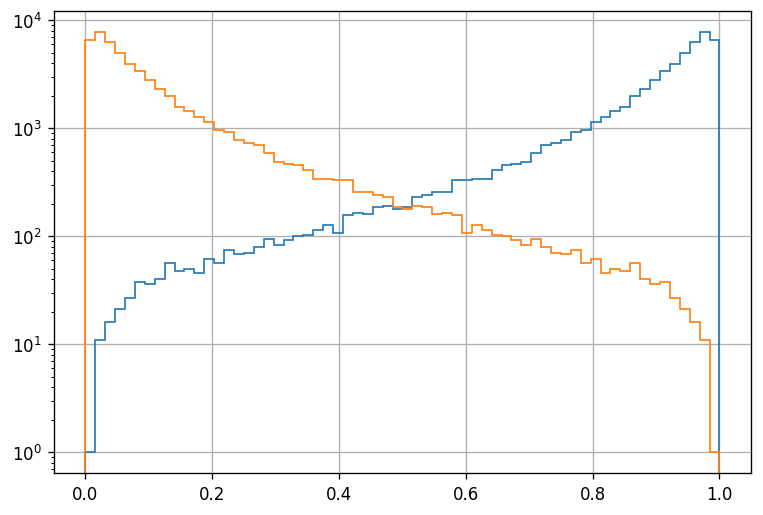

In [ ]:
_ = plt.figure(figsize=(7.5, 5), dpi=120)
_ = plt.hist(scores[:, 0], range=(0, 1), bins=64, histtype="step")
_ = plt.hist(scores[:, 1], range=(0, 1), bins=64, histtype="step")
_ = plt.yscale("log", base=10)
_ = plt.grid()